In [2]:
#Step 1: Load Dataset and Inspect 

import pandas as pd 
# Load CSV dataset 
df = pd.read_csv('StudentPerformanceFactors.csv') 

# Preview first 5 rows 
print("First 5 Rows\n",df.head()) 

First 5 Rows
    Id  Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0   1             23          84                  Low                High   
1   2             19          64                  Low              Medium   
2   3             24          98               Medium              Medium   
3   4             29          89                  Low              Medium   
4   5             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Inco

In [4]:
# Get overall info about data types and null values 
print(df.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Id                          6607 non-null   int64
 1   Hours_Studied               6607 non-null   int64
 2   Attendance                  6607 non-null   int64
 3   Parental_Involvement        6607 non-null   str  
 4   Access_to_Resources         6607 non-null   str  
 5   Extracurricular_Activities  6607 non-null   str  
 6   Sleep_Hours                 6607 non-null   int64
 7   Previous_Scores             6607 non-null   int64
 8   Motivation_Level            6607 non-null   str  
 9   Internet_Access             6607 non-null   str  
 10  Tutoring_Sessions           6607 non-null   int64
 11  Family_Income               6607 non-null   str  
 12  Teacher_Quality             6529 non-null   str  
 13  School_Type                 6607 non-null   str  
 14  Peer_Influence     

In [6]:
# Summary statistics 
print("Summary Statistics\n",df.describe(include='all')) 

Summary Statistics
                  Id  Hours_Studied   Attendance Parental_Involvement  \
count   6607.000000    6607.000000  6607.000000                 6607   
unique          NaN            NaN          NaN                    3   
top             NaN            NaN          NaN               Medium   
freq            NaN            NaN          NaN                 3362   
mean    3304.000000      19.975329    79.977448                  NaN   
std     1907.420946       5.990594    11.547475                  NaN   
min        1.000000       1.000000    60.000000                  NaN   
25%     1652.500000      16.000000    70.000000                  NaN   
50%     3304.000000      20.000000    80.000000                  NaN   
75%     4955.500000      24.000000    90.000000                  NaN   
max     6607.000000      44.000000   100.000000                  NaN   

       Access_to_Resources Extracurricular_Activities  Sleep_Hours  \
count                 6607                   

In [7]:
#Step 2: Identify Missing Values 

# Check missing values count 
print("Missing Values\n",df.isnull().sum()) 

Missing Values
 Id                             0
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Gender                         0
Exam_Score                     0
dtype: int64


In [9]:
# Calculate missing value percentage per column 
missing_percentage = df.isnull().mean() * 100 
print("missing percentage\n",missing_percentage) 

missing percentage
 Id                            0.000000
Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


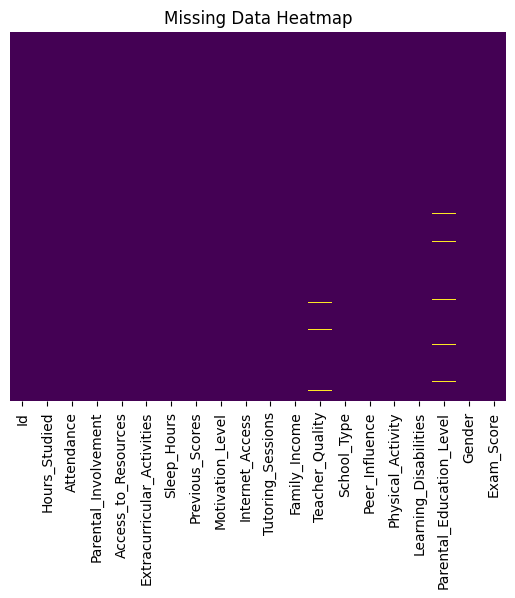

In [10]:
# Visualize missing values 
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis') 
plt.title('Missing Data Heatmap') 
plt.show() 

In [11]:
# Step 3: Handle Missing Values 

# Fill numeric columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("After cleaning:")
print(df.isnull().sum())

After cleaning:
Id                            0
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Gender                        0
Exam_Score                    0
dtype: int64


In [12]:
# Step 4: Detect and Correct Outliers 

# Method 1: IQR (Interquartile Range)

# Calculate Q1, Q3, IQR
Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_iqr_cleaned = df[(df['Exam_Score'] >= lower_bound) & (df['Exam_Score'] <= upper_bound)]

print("Original shape:", df.shape)
print("After IQR:", df_iqr_cleaned.shape)

Original shape: (6607, 20)
After IQR: (6495, 20)


In [13]:
# Step 5: Handle Duplicates 

# Count duplicate rows 
print("duplicate values\n",df.duplicated().sum())

duplicate values
 0


In [18]:
# Step 6: Correct Data Inconsistencies 

# Standardize text
df['Gender'] = df['Gender'].str.lower().str.strip()

# Replace inconsistent values
df['Gender'] = df['Gender'].replace({
    'm': 'male',
    'f': 'female',
    'male ': 'male',
    'female ': 'female'
}, inplace=True)

print(df['Gender'].unique())

<StringArray>
['male', 'female']
Length: 2, dtype: str


C:\Users\nidhi\AppData\Local\Temp\ipykernel_21456\3955176708.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'] = df['Gender'].replace({


In [17]:
# Standardize text
df['School_Type'] = df['School_Type'].str.lower().str.strip()

# Replace inconsistent values
df['School_Type'] = df['School_Type'].replace({
    'public school': 'public',
    'private school': 'private',
    'govt': 'public'
})

print(df['School_Type'].unique())

<StringArray>
['public', 'private']
Length: 2, dtype: str


In [16]:
# Select categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Apply cleaning
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

print(df.head())

   Id  Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0   1             23          84                  low                high   
1   2             19          64                  low              medium   
2   3             24          98               medium              medium   
3   4             29          89                  low              medium   
4   5             19          92               medium              medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         no            7               73              low   
1                         no            8               59              low   
2                        yes            7               91           medium   
3                        yes            8               98           medium   
4                        yes            6               65           medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Qua

C:\Users\nidhi\AppData\Local\Temp\ipykernel_21456\1363396194.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
